In [14]:
import pandas as pd
file_path = r"C:\Users\Dell\Desktop\Summer Project\online retail transaction dataset.csv"
df = pd.read_csv(file_path, encoding='cp1252')
print(df.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  


In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [16]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [17]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [19]:
df.duplicated().sum()

np.int64(5268)

In [20]:
(df['Quantity']<0).sum()

np.int64(10624)

In [21]:
(df['UnitPrice']<0).sum()

np.int64(2)

In [22]:
df[df['InvoiceNo'].str.startswith('C')].shape

(9288, 8)

In [23]:
negative_qty = df[df['Quantity'] <0]
negative_qty['InvoiceNo'].str.startswith('C').value_counts()

InvoiceNo
True     9288
False    1336
Name: count, dtype: int64

In [24]:
df[df['UnitPrice']<0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299983,A563186,B,Adjust bad debt,1,8/12/2011 14:51,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,8/12/2011 14:52,-11062.06,NaN,United Kingdom


In [ ]:
#### *Strongest Observation*
# The dataset contains a significant number of cancelled transactions and returns.

#Out of 541,909 records:
# 10,624 records contain negative quantities.
# 9,288 invoices are marked as cancelled.
# 2 records contain negative unit prices.

#These records require special handling before revenue and sales analysis to avoid misleading business insights.

In [26]:
df['CustomerID'].nunique()

4372

In [27]:
df['StockCode'].nunique()

4070

In [28]:
df['Country'].nunique()

38

In [29]:
df[df.duplicated(keep=False)].head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/2010 11:45,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,12/1/2010 11:45,2.10,17908.0,United Kingdom
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.25,17908.0,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,12/1/2010 11:45,2.95,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,12/1/2010 11:45,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,12/1/2010 11:45,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/2010 11:45,4.95,17908.0,United Kingdom
548,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,12/1/2010 11:49,2.95,17920.0,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,12/1/2010 11:49,2.95,17920.0,United Kingdom


In [30]:
df_clean=df.copy()

In [35]:
df_clean['InvoiceDate']=pd.to_datetime(df_clean['InvoiceDate'])

In [32]:
df_clean['Revenue']=(df_clean['Quantity']*df_clean['UnitPrice'])

In [33]:
df[(df['Quantity']<0)&(df['InvoiceNo'].str.startswith('C'))].head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,12/1/2010 9:41,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/2010 9:49,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,12/1/2010 10:24,3.45,17548.0,United Kingdom
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,12/1/2010 10:24,1.65,17548.0,United Kingdom
939,C536506,22960,JAM MAKING SET WITH JARS,-6,12/1/2010 12:38,4.25,17897.0,United Kingdom


In [34]:
df[df.duplicated(keep=False)].sort_values(['InvoiceNo','StockCode']).head(30)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.25,17908.0,United Kingdom
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/2010 11:45,4.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/2010 11:45,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,12/1/2010 11:45,2.10,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,12/1/2010 11:45,2.10,17908.0,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,12/1/2010 11:45,2.95,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,12/1/2010 11:45,2.95,17908.0,United Kingdom
565,536412,21448,12 DAISY PEGS IN WOOD BOX,2,12/1/2010 11:49,1.65,17920.0,United Kingdom
578,536412,21448,12 DAISY PEGS IN WOOD BOX,1,12/1/2010 11:49,1.65,17920.0,United Kingdom


In [36]:
df[
    (df['Quantity'] < 0) &
    (~df['InvoiceNo'].str.startswith('C'))
]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
2406,536589,21777,NaN,-10,12/1/2010 16:50,0.0,NaN,United Kingdom
4347,536764,84952C,NaN,-38,12/2/2010 14:42,0.0,NaN,United Kingdom
7188,536996,22712,NaN,-20,12/3/2010 15:30,0.0,NaN,United Kingdom
7189,536997,22028,NaN,-20,12/3/2010 15:30,0.0,NaN,United Kingdom
7190,536998,85067,NaN,-6,12/3/2010 15:30,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
535333,581210,23395,check,-26,12/7/2011 18:36,0.0,NaN,United Kingdom
535335,581212,22578,lost,-1050,12/7/2011 18:38,0.0,NaN,United Kingdom
535336,581213,22576,check,-30,12/7/2011 18:38,0.0,NaN,United Kingdom
536908,581226,23090,missing,-338,12/8/2011 9:56,0.0,NaN,United Kingdom


In [37]:
df_clean = df.copy()

In [38]:
df_clean = df_clean.drop_duplicates()

In [39]:
df_clean = df_clean[df_clean['UnitPrice'] > 0]

In [40]:
df_clean['Revenue'] = (
    df_clean['Quantity'] *
    df_clean['UnitPrice']
)

In [41]:
df['StockCode'].nunique()

4070

In [42]:
df['InvoiceNo'].nunique()

25900

In [43]:
df['Country'].value_counts().head(10)

Country
United Kingdom    495478
Germany             9495
France              8557
EIRE                8196
Spain               2533
Netherlands         2371
Belgium             2069
Switzerland         2002
Portugal            1519
Australia           1259
Name: count, dtype: int64

In [44]:
df['InvoiceDate'].min(), df['InvoiceDate'].max()

('1/10/2011 10:04', '9/9/2011 9:52')

In [45]:
df_clean['InvoiceDate'].min(), df_clean['InvoiceDate'].max()

('1/10/2011 10:07', '9/9/2011 9:52')

In [46]:
df_sales = df_clean[
    (df_clean['Quantity'] > 0) &
    (df_clean['UnitPrice'] > 0)
].copy()

In [47]:
df_sales['Revenue'] = (
    df_sales['Quantity'] *
    df_sales['UnitPrice']
)

In [48]:
df_sales.shape

(524878, 9)

In [49]:
df_sales[['Quantity','UnitPrice','Revenue']].head()

,Quantity,UnitPrice,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [50]:
df_sales['Revenue'].describe()

count    524878.000000
mean         20.275399
std         271.693566
min           0.001000
25%           3.900000
50%           9.920000
75%          17.700000
max      168469.600000
Name: Revenue, dtype: float64

In [51]:
## EDA - Revenue Analysis

In [52]:
## Total Revenue
total_revenue = df_sales['Revenue'].sum()
print(f"Total Revenue: £{total_revenue:,.2f}")

Total Revenue: £10,642,110.80


In [53]:
## Monthly Revenue Trend
monthly_revenue = (
    df_sales
    .groupby(df_sales['InvoiceDate'].dt.to_period('M'))['Revenue']
    .sum()
)

monthly_revenue.plot(figsize=(10,5))
plt.title('Monthly Revenue Trend')
plt.ylabel('Revenue (£)')
plt.show()

AttributeError: Can only use .dt accessor with datetimelike values

In [54]:
df_sales['InvoiceDate'].dtype

<StringDtype(storage='python', na_value=nan)>

In [56]:
df_sales['InvoiceDate'] = pd.to_datetime(df_sales['InvoiceDate'])

In [57]:
df_sales['InvoiceDate'].dtype

dtype('<M8[us]')

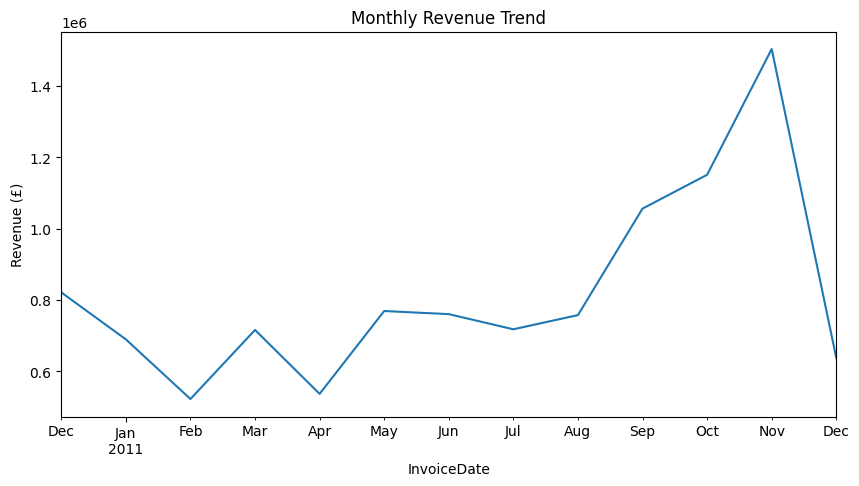

In [59]:
monthly_revenue = (
    df_sales
    .groupby(df_sales['InvoiceDate'].dt.to_period('M'))['Revenue']
    .sum()
)
import matplotlib.pyplot as plt
monthly_revenue.plot(figsize=(10,5))
plt.title('Monthly Revenue Trend')
plt.ylabel('Revenue (£)')
plt.show()

In [60]:
monthly_revenue.head()

InvoiceDate
2010-12    821452.730
2011-01    689811.610
2011-02    522545.560
2011-03    716215.260
2011-04    536968.491
Freq: M, Name: Revenue, dtype: float64

In [ ]:
### Insight

#Revenue shows clear seasonality.
#Sales increased significantly from September to November 2011,with November generating the highest revenue in the dataset.
#February and April recorded the lowest revenue levels.
#The decline in December 2011 should be interpreted cautiously, as the dataset contains only a partial month of data.

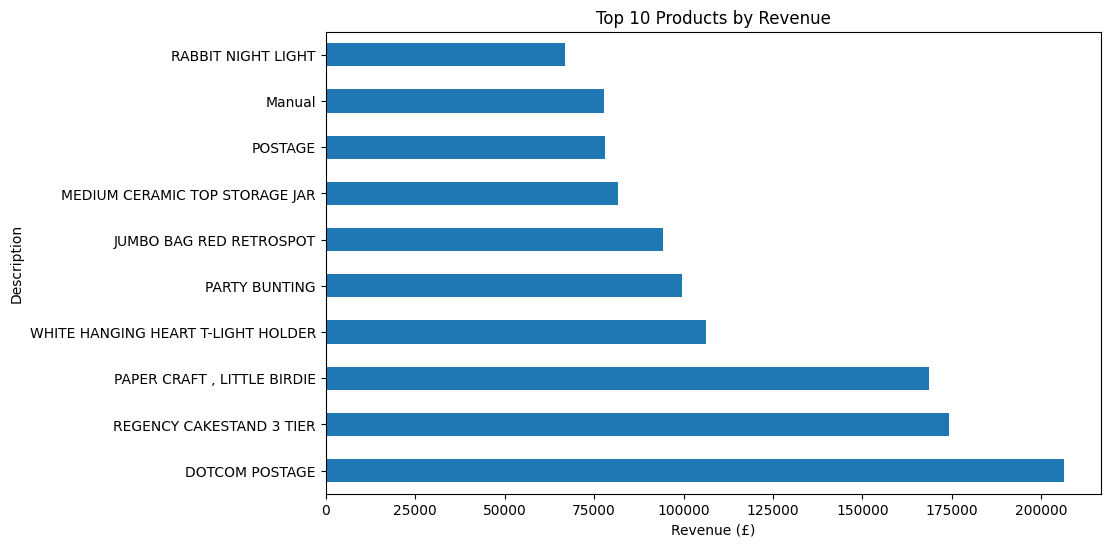

In [62]:
## Top 10 Products By Revenue
top_products = (
    df_sales
    .groupby('Description')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products.plot(kind='barh', figsize=(10,6))
plt.title('Top 10 Products by Revenue')
plt.xlabel('Revenue (£)')
plt.show()

In [ ]:
## Insight

# A small number of products contribute disproportionately to revenue.
# The highest-revenue items are home décor, gift, and party-related products, suggesting strong demand for lifestyle and decorative goods.

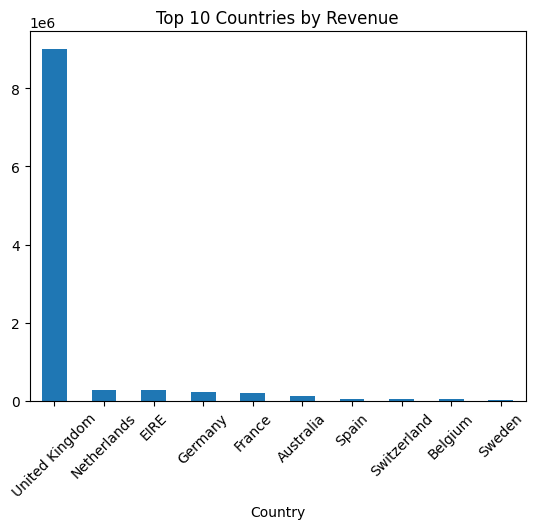

In [63]:
## Top 10 Countries By Revenue
country_revenue = (
    df_sales
    .groupby('Country')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

country_revenue.plot(kind='bar')
plt.title('Top 10 Countries by Revenue')
plt.xticks(rotation=45)
plt.show()

In [64]:
country_revenue = (
    df_sales
    .groupby('Country')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(country_revenue)

Country
United Kingdom    9001744.094
Netherlands        285446.340
EIRE               283140.520
Germany            228678.400
France             209625.370
Australia          138453.810
Spain               61558.560
Switzerland         57067.600
Belgium             41196.340
Sweden              38367.830
Name: Revenue, dtype: float64


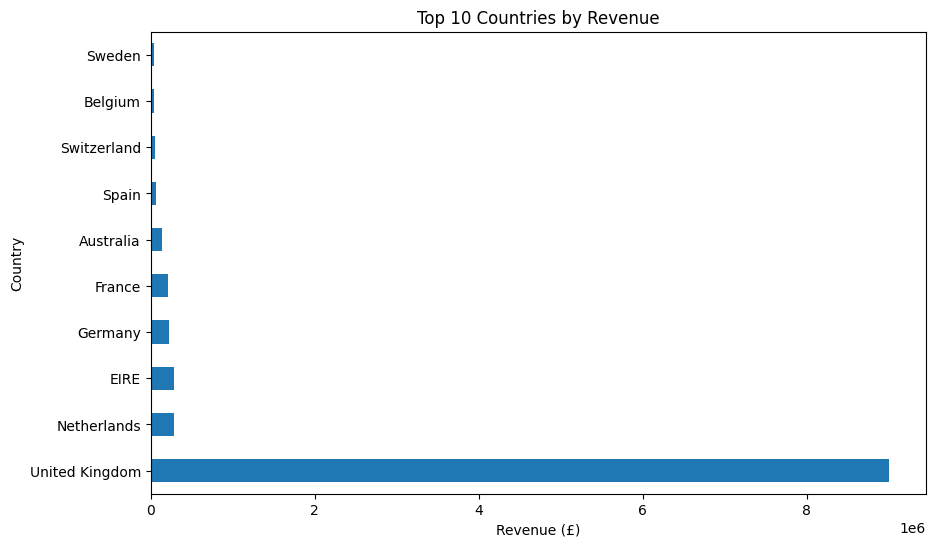

In [65]:
country_revenue.plot(
    kind='barh',
    figsize=(10,6)
)

plt.title('Top 10 Countries by Revenue')
plt.xlabel('Revenue (£)')
plt.show()

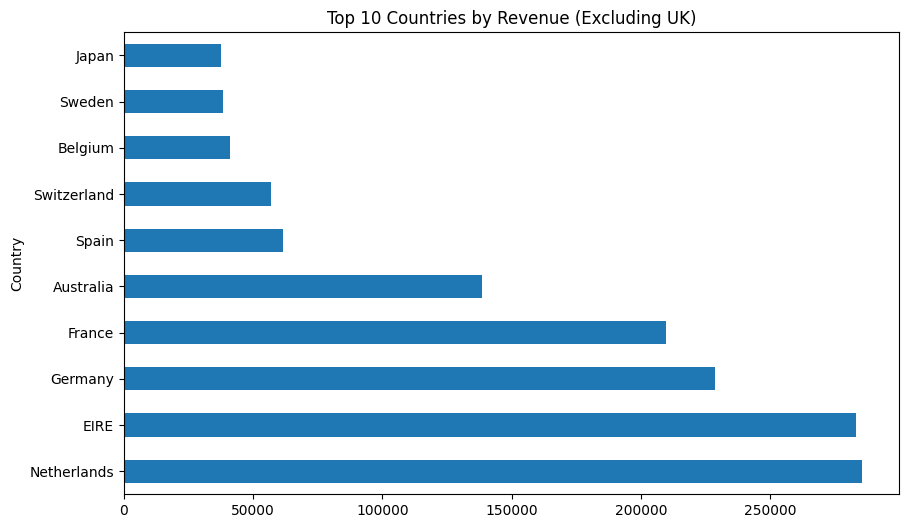

In [66]:
country_revenue_no_uk = (
    df_sales[df_sales['Country'] != 'United Kingdom']
    .groupby('Country')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

country_revenue_no_uk.plot(kind='barh', figsize=(10,6))
plt.title('Top 10 Countries by Revenue (Excluding UK)')
plt.show()

In [ ]:
### Insight

# The United Kingdom is the dominant market, contributing the vast majority of revenue.
# Among international markets, the Netherlands, EIRE, and Germany are the strongest contributors.

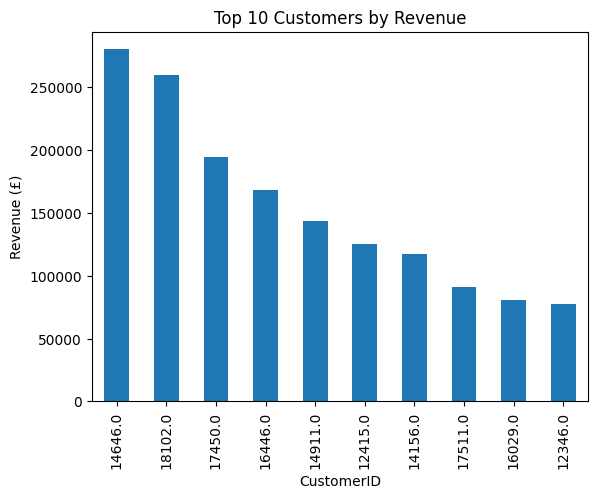

In [67]:
top_customers = (
    df_sales
    .groupby('CustomerID')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers.plot(kind='bar')
plt.title('Top 10 Customers by Revenue')
plt.ylabel('Revenue (£)')
plt.show()

In [68]:
top_customers

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
12415.0    124914.53
14156.0    117210.08
17511.0     91062.38
16029.0     80850.84
12346.0     77183.60
Name: Revenue, dtype: float64

In [69]:
top_10_customer_revenue = top_customers.sum()
total_revenue = df_sales['Revenue'].sum()
(top_10_customer_revenue / total_revenue) * 100

np.float64(14.448817892612501)

In [ ]:
### Insight

# The top 10 customers account for approximately 14.45% of total revenue.
# Revenue is somewhat concentrated among a small group of high-value customers, indicating the importance of customer retention strategies for these buyers.

In [70]:
df_sales['CustomerID'] = (
    df_sales['CustomerID']
    .astype('Int64')
)

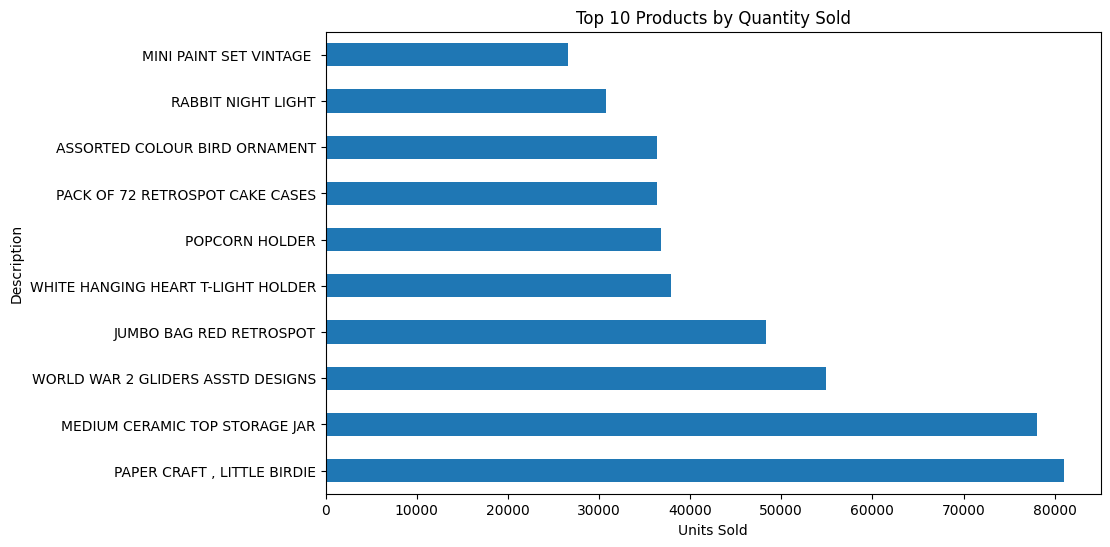

In [71]:
### Top Products By Quantity Sold
top_quantity = (
    df_sales
    .groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_quantity.plot(kind='barh', figsize=(10,6))
plt.title('Top 10 Products by Quantity Sold')
plt.xlabel('Units Sold')
plt.show()

In [ ]:
### Product Analysis Insight

# Some products appear in both rankings, while others do not.
# This indicates that certain products drive revenue through high volume sales, whereas others generate revenue because of higher prices.

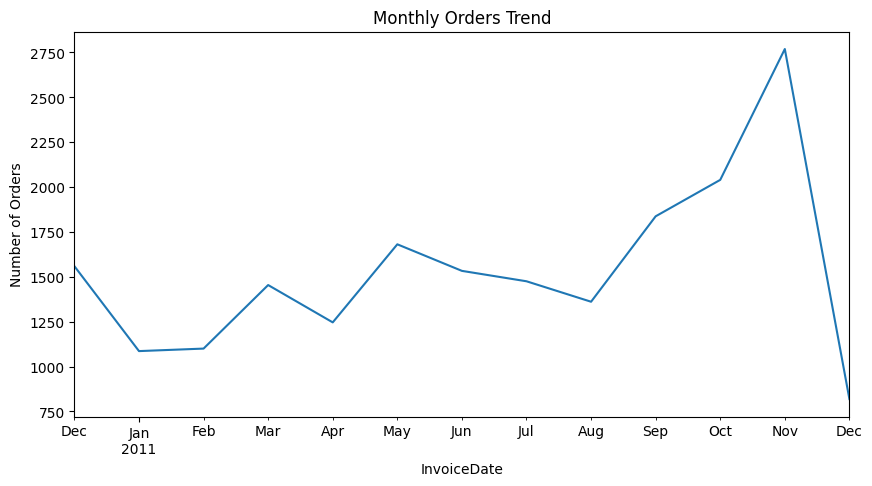

In [72]:
### Monthly Order Trend
monthly_orders = (
    df_sales
    .groupby(df_sales['InvoiceDate'].dt.to_period('M'))['InvoiceNo']
    .nunique()
)

monthly_orders.plot(figsize=(10,5))
plt.title('Monthly Orders Trend')
plt.ylabel('Number of Orders')
plt.show()

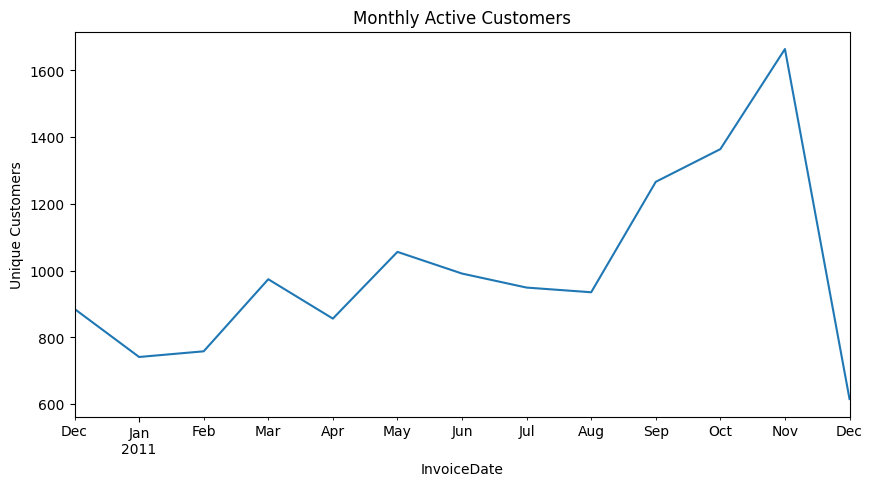

In [73]:
### Monthly Customers Trend
monthly_customers = (
    df_sales
    .groupby(df_sales['InvoiceDate'].dt.to_period('M'))['CustomerID']
    .nunique()
)

monthly_customers.plot(figsize=(10,5))
plt.title('Monthly Active Customers')
plt.ylabel('Unique Customers')
plt.show()

In [75]:
### Insight

# More customers → More orders → More revenue
# Revenue growth from September to November 2011 was driven by both an increase in active customers and a rise in order volume.
# November recorded the highest revenue, highest number of orders, and highest number of active customers, indicating strong seasonal demand.

In [76]:
### Average Order Value

order_revenue = (
    df_sales
    .groupby('InvoiceNo')['Revenue']
    .sum()
)

aov = order_revenue.mean()

print(f'Average Order Value: £{aov:,.2f}')

Average Order Value: £533.17


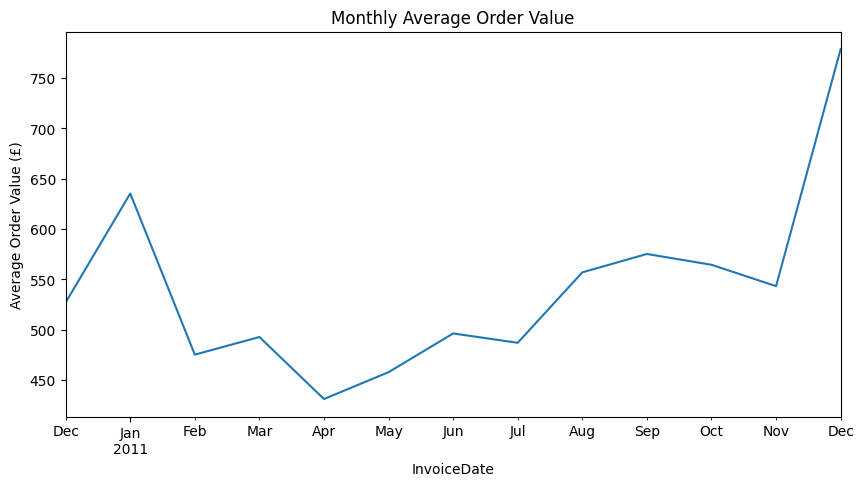

In [78]:
## Monthly AOV
invoice_data = (
    df_sales
    .groupby('InvoiceNo')
    .agg({
        'Revenue':'sum',
        'InvoiceDate':'first'
    })
)

monthly_aov = (
    invoice_data
    .groupby(invoice_data['InvoiceDate'].dt.to_period('M'))['Revenue']
    .mean()
)

monthly_aov.plot(figsize=(10,5))
plt.title('Monthly Average Order Value')
plt.ylabel('Average Order Value (£)')
plt.show()

In [79]:
### December 2011 shows unusually high average order value, but the month contains incomplete data and should be interpreted with caution.

In [80]:
df_sales.to_csv('online_retail_cleaned.csv', index=False)

In [81]:
import os
os.listdir()

['-1.14-windows.xml',
 '.aws',
 '.cache',
 '.idlerc',
 '.ipynb_checkpoints',
 '.ipython',
 '.jupyter',
 '.Ld2VirtualBox',
 '.matplotlib',
 '.node_repl_history',
 '.vscode',
 '3D Objects',
 'amazon_analysis.ipynb',
 'AppData',
 'Application Data',
 'AWSCLIV2.pkg',
 'bestuubirthday',
 'Contacts',
 'Cookies',
 'Desktop',
 'Documents',
 'downloaded.txt',
 'Downloads',
 'Favorites',
 'foodpanda.csv',
 'inst.ini',
 'IntelGraphicsProfiles',
 'Links',
 'Local Settings',
 'MicrosoftEdgeBackups',
 'Music',
 'My Documents',
 'NetHood',
 'NTUSER.DAT',
 'ntuser.dat.LOG1',
 'ntuser.dat.LOG2',
 'NTUSER.DAT{9809e88f-6efd-11f0-96a1-b5829cb4a1b8}.TM.blf',
 'NTUSER.DAT{9809e88f-6efd-11f0-96a1-b5829cb4a1b8}.TMContainer00000000000000000001.regtrans-ms',
 'NTUSER.DAT{9809e88f-6efd-11f0-96a1-b5829cb4a1b8}.TMContainer00000000000000000002.regtrans-ms',
 'ntuser.ini',
 'nuuid.ini',
 'OneDrive',
 'online_retail_cleaned.csv',
 'Pictures',
 'PrintHood',
 'pushuu.py',
 'Recent',
 'sales_analysis.ipynb',
 'Saved Gam

In [85]:
os.path.exists('online_retail_cleaned.csv')

True

In [86]:
### RFM Customer Segmentation 
# Recency - How well the customer purchased
# Frequency - How often they purchased
# Monetary - How much they spend

In [97]:
# RFM dataset
rfm_df = df_sales[df_sales['CustomerID'].notna()].copy()

In [98]:
# Snapshot Date
snapshot_date = rfm_df['InvoiceDate'].max() + pd.Timedelta(days=1)

print(snapshot_date)

2011-12-10 12:50:00


In [99]:
# RFM Table
rfm = rfm_df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'Revenue': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,77183.60
12347,2,7,4310.00
12348,75,4,1797.24
12349,19,1,1757.55
12350,310,1,334.40


In [100]:
# Explore RFM
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


In [101]:
# RFM Score
rfm['R_Score'] = pd.qcut(
    rfm['Recency'],
    4,
    labels=[4,3,2,1]
)

rfm['F_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    4,
    labels=[1,2,3,4]
)

rfm['M_Score'] = pd.qcut(
    rfm['Monetary'],
    4,
    labels=[1,2,3,4]
)

In [102]:
# Overall RFM Score
rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str) +
    rfm['F_Score'].astype(str) +
    rfm['M_Score'].astype(str)
)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,,,,
12346,326,1,77183.60,1,1,4,114
12347,2,7,4310.00,4,4,4,444
12348,75,4,1797.24,2,3,4,234
12349,19,1,1757.55,3,1,4,314
12350,310,1,334.40,1,1,2,112


In [103]:
# Identify Best Customers
best_customers = rfm[
    rfm['RFM_Score'] == '444'
]

print(best_customers.shape)

(489, 7)


In [104]:
# Segment Customers
def segment_customer(row):

    if row['RFM_Score'] == '444':
        return 'Champions'

    elif row['R_Score'] >= 3 and row['F_Score'] >= 3:
        return 'Loyal Customers'

    elif row['R_Score'] == 4:
        return 'Recent Customers'

    elif row['R_Score'] <= 2:
        return 'At Risk'

    else:
        return 'Others'

In [106]:
rfm['Segment'] = rfm.apply(
    segment_customer,
    axis=1
)

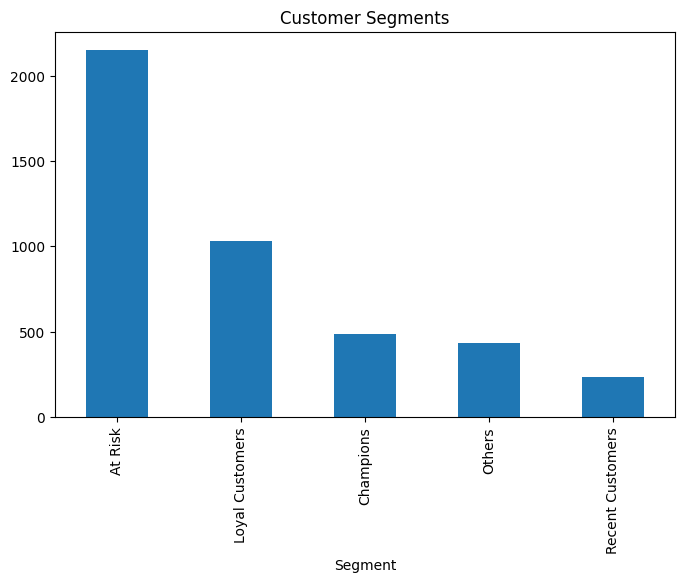

In [107]:
# Visualize Segment
rfm['Segment'].value_counts().plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Customer Segments')
plt.show()

In [108]:
rfm['Segment'].value_counts()

Segment
At Risk             2150
Loyal Customers     1034
Champions            489
Others               431
Recent Customers     234
Name: count, dtype: int64

In [109]:
segment_pct = (
    rfm['Segment']
    .value_counts(normalize=True)
    * 100
)

print(segment_pct)

Segment
At Risk             49.562010
Loyal Customers     23.835869
Champions           11.272476
Others               9.935454
Recent Customers     5.394191
Name: proportion, dtype: float64


In [ ]:
# Insight

# Customer spending is highly skewed.
# While the average customer generates approximately £2,049 in revenue, the median customer generates only £669, indicating that a small group of high-value customers contributes disproportionately to revenue.

In [110]:
rfm.to_csv('customer_rfm_segments.csv')